# **Customer Segmentation**

In [85]:
y_prob = rf_tuned.predict_proba(X)
churn_prob = y_prob[:, 1]

segmentation_data=pd.DataFrame({
    'Tenure Months':X['Tenure Months'],
    'Monthly Charges':X['Monthly Charges'],
    'Total Charges':X['Total Charges'],
    'Churn  Probability':churn_prob
})

In [86]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.84
1,2,70.70,151.65,0.83
2,8,99.65,820.50,0.90
3,28,104.80,3046.05,0.75
4,49,103.70,5036.30,0.64
...,...,...,...,...
7038,72,21.15,1419.40,0.01
7039,24,84.80,1990.50,0.01
7040,72,103.20,7362.90,0.00
7041,11,29.60,346.45,0.33


# **Inspect the `segmentation_data` for any Missing Values**

In [87]:
print(f"Number of rows before dropping NaNs: {len(segmentation_data)}")
segmentation_data_cleaned = segmentation_data.dropna().copy()
print(f"Number of rows after dropping NaNs: {len(segmentation_data_cleaned)}")

Number of rows before dropping NaNs: 7043
Number of rows after dropping NaNs: 7032


In [88]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# **K-Means Elbow Method**

In [89]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data_cleaned = scaler.fit_transform(segmentation_data_cleaned)
print(scaled_data_cleaned[:5])

[[-1.23950408 -0.36392329 -0.95964911  1.80554734]
 [-1.23950408  0.19617818 -0.94045745  1.77414375]
 [-0.99504031  1.15848901 -0.64536922  1.99396886]
 [-0.18016108  1.3296773   0.33651554  1.52291505]
 [ 0.6754621   1.29311281  1.2145889   1.17747559]]


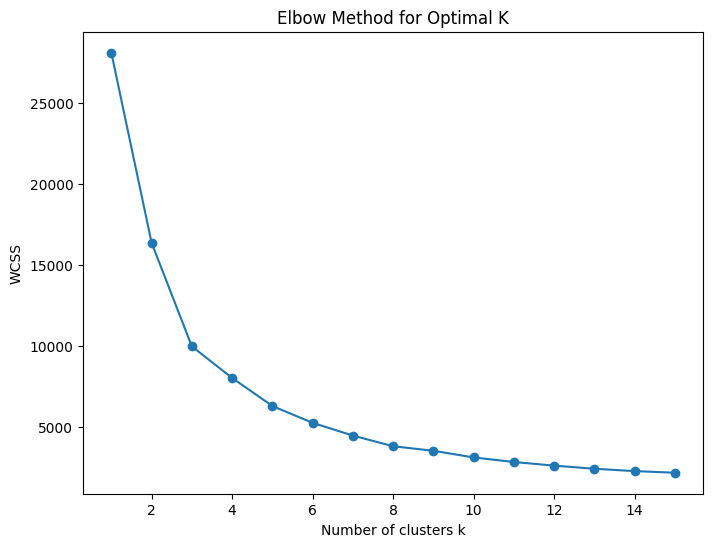

In [90]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42, n_init='auto')
  kmeans.fit(scaled_data_cleaned)
  wcss.append(kmeans.inertia_)
# Move plotting outside the loop
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

# **3 Clusters for K-Means**

In [91]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(scaled_data_cleaned)
segmentation_data_cleaned['cluster'] = clusters
print(segmentation_data_cleaned.head())

   Tenure Months  Monthly Charges  Total Charges  Churn  Probability  cluster
0              2            53.85         108.15                0.84        2
1              2            70.70         151.65                0.83        2
2              8            99.65         820.50                0.90        2
3             28           104.80        3046.05                0.75        2
4             49           103.70        5036.30                0.64        0


In [92]:
cluster_summary = segmentation_data_cleaned.groupby('cluster').mean()
print(cluster_summary)

         Tenure Months  Monthly Charges  Total Charges  Churn  Probability
cluster                                                                   
0            57.791553        90.253065    5204.786603            0.134777
1            27.658228        38.496642     980.582947            0.071071
2            11.114300        74.239325     909.592497            0.687277


# **Implementation Of K-means**

In [93]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [94]:
scaled_data = scaler.fit_transform(segmentation_data_cleaned)
print(scaled_data[:5])

[[-1.23950408 -0.36392329 -0.95964911  1.80554734  1.33665616]
 [-1.23950408  0.19617818 -0.94045745  1.77414375  1.33665616]
 [-0.99504031  1.15848901 -0.64536922  1.99396886  1.33665616]
 [-0.18016108  1.3296773   0.33651554  1.52291505  1.33665616]
 [ 0.6754621   1.29311281  1.2145889   1.17747559 -1.25698791]]


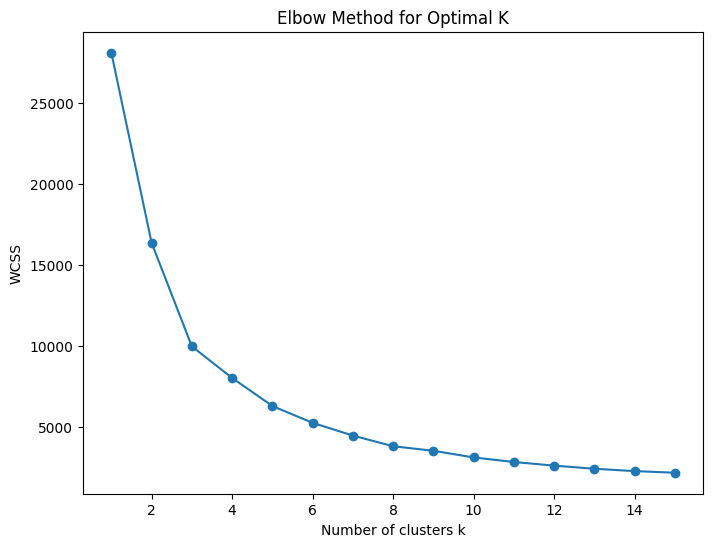

In [95]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k,random_state=42, n_init='auto')
  kmeans.fit(scaled_data_cleaned)
  wcss.append(kmeans.inertia_)
# Move plotting outside the loop
plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of clusters k")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal K")
plt.show()

In [96]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')

In [97]:
clusters=kmeans.fit_predict(scaled_data_cleaned)

In [98]:
segmentation_data_cleaned

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster
0,2,53.85,108.15,0.84,2
1,2,70.70,151.65,0.83,2
2,8,99.65,820.50,0.90,2
3,28,104.80,3046.05,0.75,2
4,49,103.70,5036.30,0.64,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.01,1
7039,24,84.80,1990.50,0.01,1
7040,72,103.20,7362.90,0.00,0
7041,11,29.60,346.45,0.33,1


In [99]:
segmentation_data_cleaned['cluster'] = clusters

In [100]:
segmentation_data_cleaned

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster
0,2,53.85,108.15,0.84,2
1,2,70.70,151.65,0.83,2
2,8,99.65,820.50,0.90,2
3,28,104.80,3046.05,0.75,2
4,49,103.70,5036.30,0.64,0
...,...,...,...,...,...
7038,72,21.15,1419.40,0.01,1
7039,24,84.80,1990.50,0.01,1
7040,72,103.20,7362.90,0.00,0
7041,11,29.60,346.45,0.33,1


In [101]:
cluster_summary = segmentation_data_cleaned.groupby('cluster').mean()

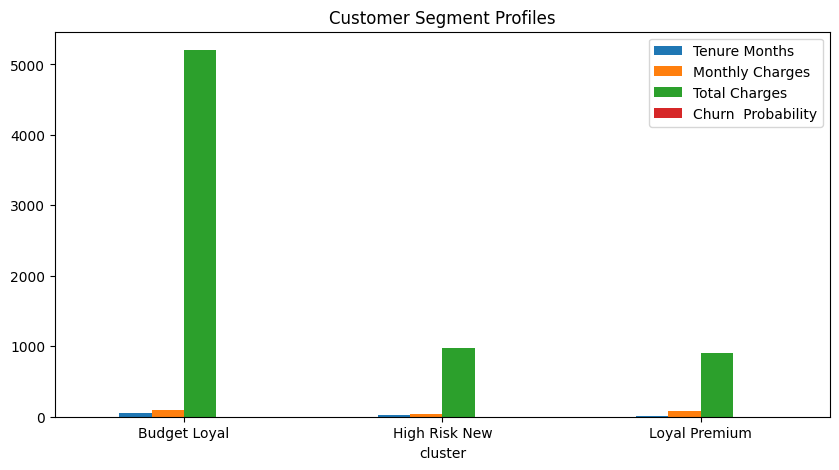

In [102]:
cluster_summary.plot(kind='bar', figsize=(10,5))
plt.title('Customer Segment Profiles')
plt.xticks(ticks=[0,1,2], labels=['Budget Loyal','High Risk New','Loyal Premium'], rotation=0)
plt.show()

In [103]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
cluster,,,,
0,57.791553,90.253065,5204.786603,0.134777
1,27.658228,38.496642,980.582947,0.071071
2,11.114300,74.239325,909.592497,0.687277


In [104]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2: 'Loyal Premium Customers'
    }

In [105]:
segmentation_data_cleaned['Cluster Segment'] = segmentation_data_cleaned['cluster'].map(cluster_names)

In [106]:
segmentation_data_cleaned

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,cluster,Cluster Segment
0,2,53.85,108.15,0.84,2,Loyal Premium Customers
1,2,70.70,151.65,0.83,2,Loyal Premium Customers
2,8,99.65,820.50,0.90,2,Loyal Premium Customers
3,28,104.80,3046.05,0.75,2,Loyal Premium Customers
4,49,103.70,5036.30,0.64,0,Budget Loyal Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.01,1,High Risk New Customers
7039,24,84.80,1990.50,0.01,1,High Risk New Customers
7040,72,103.20,7362.90,0.00,0,Budget Loyal Customers
7041,11,29.60,346.45,0.33,1,High Risk New Customers


In [107]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Monthly Charges', ylabel='Churn  Probability'>

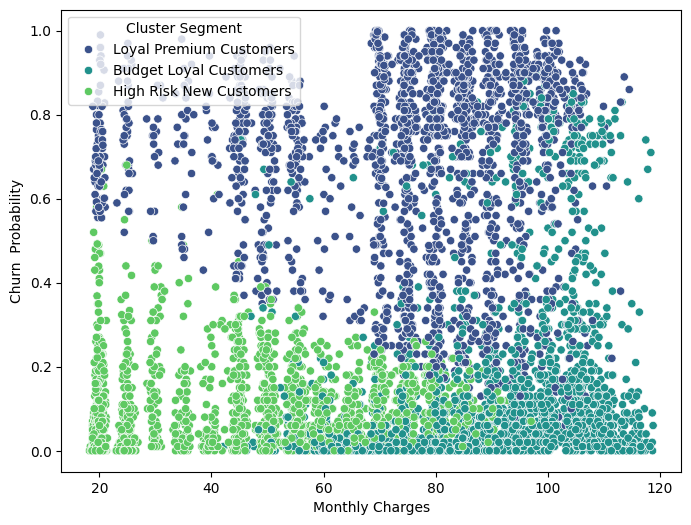

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.scatterplot(x='Monthly Charges',y='Churn  Probability',hue='Cluster Segment',data=segmentation_data_cleaned,palette='viridis')

<Axes: xlabel='Tenure Months', ylabel='Churn  Probability'>

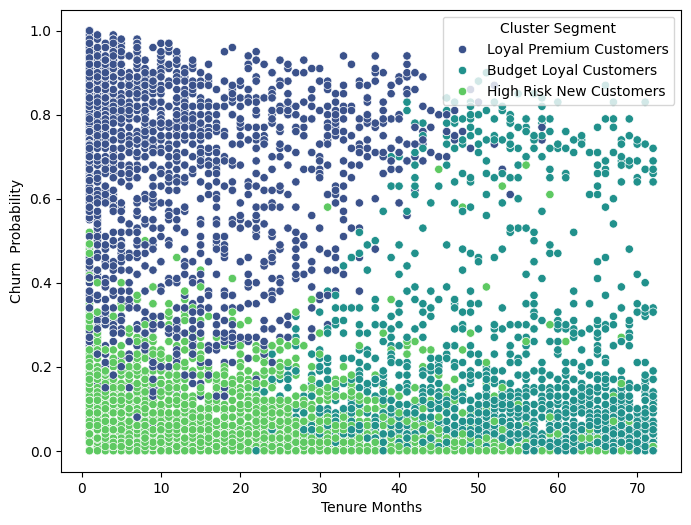

In [109]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months',y='Churn  Probability',hue='Cluster Segment',data=segmentation_data_cleaned,palette='viridis')

<Axes: xlabel='Total Charges', ylabel='Churn  Probability'>

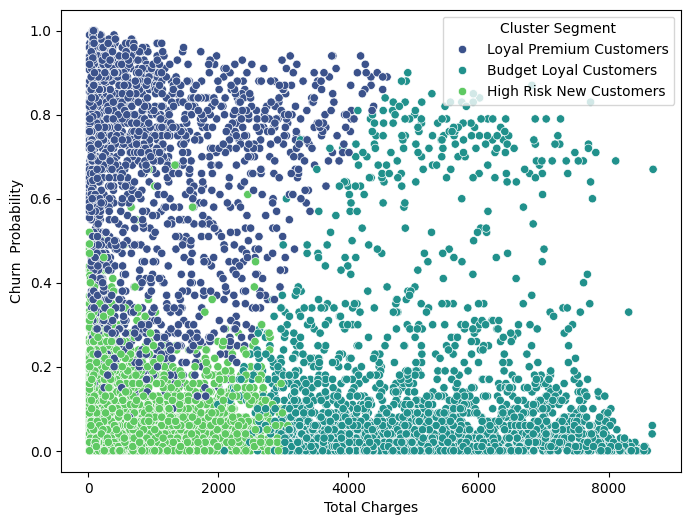

In [110]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Total Charges',y='Churn  Probability',hue='Cluster Segment',data=segmentation_data_cleaned,palette='viridis')